In [1]:
# SECTION 1: IMPORTS

import pandas as pd              # Tables / DataFrames
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Base plotting library
import seaborn as sns            # Statistical visualizations

sns.set_style("whitegrid")
sns.set_context("notebook")

# SECTION 2: LOAD DATA

file_path = "final_assessment_studentdata.csv"
df = pd.read_csv("C:\\Users\\Taufique Ahmed\\Desktop\\Final Assessment\\final_assessment_studentdata.csv")


In [2]:
# SECTION 3: DATA INSPECTION

# Column names
print("Columns:")
print(df.columns)

# Data types and missing overview
print("\nDataset info:")
df.info()

# Quick statistics for numeric columns
print("\nNumeric summary:")
# Remove the numeric_only parameter as it's not supported in this pandas version
display(df.describe())

Columns:
Index(['student_id', 'name', 'program', 'gender', 'age', 'study_mode',
       'gpa_sem1', 'gpa_sem2', 'attendance_rate', 'hours_studied_per_week',
       'co_curricular', 'fee_payment_status', 'overall_gpa'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              300 non-null    int64  
 1   name                    300 non-null    object 
 2   program                 300 non-null    object 
 3   gender                  300 non-null    object 
 4   age                     300 non-null    int64  
 5   study_mode              300 non-null    object 
 6   gpa_sem1                300 non-null    float64
 7   gpa_sem2                292 non-null    float64
 8   attendance_rate         290 non-null    float64
 9   hours_studied_per_week  290 non-null    float64
 10 

,student_id,age,gpa_sem1,gpa_sem2,attendance_rate,hours_studied_per_week,overall_gpa
count,300.000000,300.000000,300.000000,292.000000,290.000000,290.000000,300.000000
mean,5150.500000,23.106667,2.728733,2.796884,84.495862,9.890690,2.758733
std,86.746758,3.329501,0.600917,0.668199,9.307655,3.954851,0.603359
min,5001.000000,18.000000,1.330000,0.790000,50.000000,2.000000,1.060000
25%,5075.750000,20.000000,2.320000,2.307500,78.325000,6.800000,2.320000
50%,5150.500000,23.000000,2.700000,2.880000,84.450000,10.350000,2.760000
75%,5225.250000,26.000000,3.157500,3.260000,91.575000,12.900000,3.202500
max,5300.000000,29.000000,4.000000,4.000000,100.000000,20.000000,4.000000


In [3]:
# SECTION 4: DATA QUALITY CHECKS

# 4.1 Missing values (count + percent)
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct.round(2)
})

print("Missing values summary:")
display(missing_summary)

# 4.2 Duplicate checks
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate student_id:", df["student_id"].duplicated().sum())

# 4.3 Validate overall_gpa = average(gpa_sem1, gpa_sem2)
# Only possible when gpa_sem2 is present (non-null)
calc_overall = (df["gpa_sem1"] + df["gpa_sem2"]) / 2
diff = df["overall_gpa"] - calc_overall
valid_diff = diff.dropna()

print("\nOverall GPA validation (difference between stored overall_gpa and calculated):")
print("Max abs diff:", valid_diff.abs().max())
print("Mean abs diff:", valid_diff.abs().mean())

Missing values summary:


,missing_count,missing_percent
co_curricular,89,29.67
attendance_rate,10,3.33
hours_studied_per_week,10,3.33
gpa_sem2,8,2.67
student_id,0,0.00
name,0,0.00
program,0,0.00
gender,0,0.00
age,0,0.00
study_mode,0,0.00


Duplicate rows: 0
Duplicate student_id: 0

Overall GPA validation (difference between stored overall_gpa and calculated):
Max abs diff: 0.0050000000000003375
Mean abs diff: 0.0025513698630137095


In [4]:
# SECTION 5: DATA CLEANING

df_clean = df.copy()

# 5.1 co_curricular: label missing as "Unknown"
df_clean["co_curricular"] = df_clean["co_curricular"].fillna("Unknown")

# 5.2 attendance_rate & hours_studied_per_week: fill missing using median per program
for col in ["attendance_rate", "hours_studied_per_week"]:
    df_clean[col] = df_clean.groupby("program")[col].transform(lambda s: s.fillna(s.median()))

# 5.3 gpa_sem2: reconstruct when missing using:
# overall_gpa = (gpa_sem1 + gpa_sem2)/2  =>  gpa_sem2 = 2*overall_gpa - gpa_sem1
mask_sem2_missing = df_clean["gpa_sem2"].isna()
df_clean.loc[mask_sem2_missing, "gpa_sem2"] = (
    2 * df_clean.loc[mask_sem2_missing, "overall_gpa"] - df_clean.loc[mask_sem2_missing, "gpa_sem1"]
)

# Post-cleaning missing check
print("Missing values after cleaning:")
display(df_clean.isnull().sum().sort_values(ascending=False))


Missing values after cleaning:


student_id                0
name                      0
program                   0
gender                    0
age                       0
study_mode                0
gpa_sem1                  0
gpa_sem2                  0
attendance_rate           0
hours_studied_per_week    0
co_curricular             0
fee_payment_status        0
overall_gpa               0
dtype: int64

In [38]:
# SECTION 6: FEATURE ENGINEERING

# GPA change between semesters
df_clean["gpa_change"] = df_clean["gpa_sem2"] - df_clean["gpa_sem1"]
df_clean["improved"] = df_clean["gpa_change"] > 0

# At-risk rules 
df_clean["risk_low_gpa"] = df_clean["overall_gpa"] < 2.0
df_clean["risk_low_attendance"] = df_clean["attendance_rate"] < 75
df_clean["risk_fee_outstanding"] = df_clean["fee_payment_status"].eq("Outstanding")

# Combine to a single flag
df_clean["at_risk"] = df_clean[["risk_low_gpa", "risk_low_attendance", "risk_fee_outstanding"]].any(axis=1)

# Quick summary
print("At-risk count:", df_clean["at_risk"].sum())
print("At-risk %:", round(df_clean["at_risk"].mean()*100, 2))

At-risk count: 123
At-risk %: 41.0


In [6]:
# SECTION 7: STATISTICAL SUMMARIES

numeric_cols = ["age", "gpa_sem1", "gpa_sem2", "attendance_rate", "hours_studied_per_week", "overall_gpa"]

# 7.1 Descriptive stats table
desc_table = df_clean[numeric_cols].describe().T.round(3)
display(desc_table)

# 7.2 Group summaries (use these tables in report)
gpa_by_program = df_clean.groupby("program")["overall_gpa"].agg(["count","mean","median","std"]).round(3).sort_values("mean", ascending=False)
gpa_by_mode    = df_clean.groupby("study_mode")["overall_gpa"].agg(["count","mean","median","std"]).round(3)
gpa_by_gender  = df_clean.groupby("gender")["overall_gpa"].agg(["count","mean","median","std"]).round(3)
gpa_by_fee     = df_clean.groupby("fee_payment_status")["overall_gpa"].agg(["count","mean","median","std"]).round(3)

print("GPA by Program")
display(gpa_by_program)

print("GPA by Study Mode")
display(gpa_by_mode)

print("GPA by Gender")
display(gpa_by_gender)

print("GPA by Fee Status")
display(gpa_by_fee)

,count,mean,std,min,25%,50%,75%,max
age,300.0,23.107,3.330,18.00,20.000,23.00,26.000,29.0
gpa_sem1,300.0,2.729,0.601,1.33,2.320,2.70,3.157,4.0
gpa_sem2,300.0,2.788,0.665,0.79,2.300,2.88,3.252,4.0
attendance_rate,300.0,84.522,9.156,50.00,78.400,84.80,91.425,100.0
hours_studied_per_week,300.0,9.917,3.892,2.00,6.975,10.50,12.800,20.0
overall_gpa,300.0,2.759,0.603,1.06,2.320,2.76,3.202,4.0


GPA by Program


,count,mean,median,std
program,,,,
Diploma IT,98,2.843,2.86,0.577
BSc SE,53,2.731,2.76,0.647
Diploma CS,70,2.724,2.74,0.602
BSc CS,79,2.703,2.66,0.607


GPA by Study Mode


,count,mean,median,std
study_mode,,,,
Full-Time,234,2.751,2.75,0.596
Part-Time,66,2.787,2.84,0.634


GPA by Gender


,count,mean,median,std
gender,,,,
F,160,2.778,2.77,0.595
M,140,2.736,2.75,0.614


GPA by Fee Status


,count,mean,median,std
fee_payment_status,,,,
Outstanding,63,2.761,2.81,0.549
Paid,237,2.758,2.76,0.618


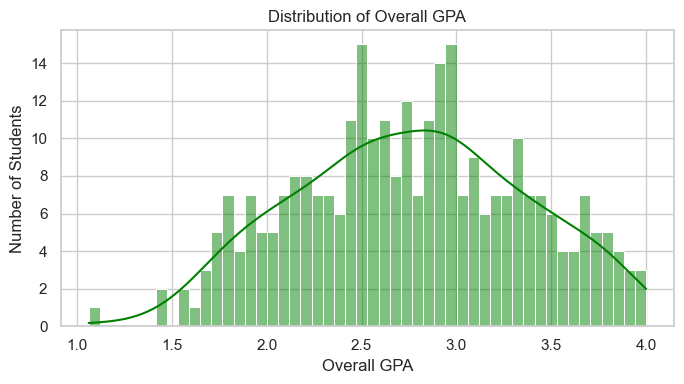

In [17]:
# SECTION 9.1: GPA DISTRIBUTION

plt.figure(figsize=(7,4))
# Added color="green" parameter to set the histogram bars to green
sns.histplot(df_clean["overall_gpa"], bins=50, kde=True, color="green")
plt.title("Distribution of Overall GPA")
plt.xlabel("Overall GPA")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

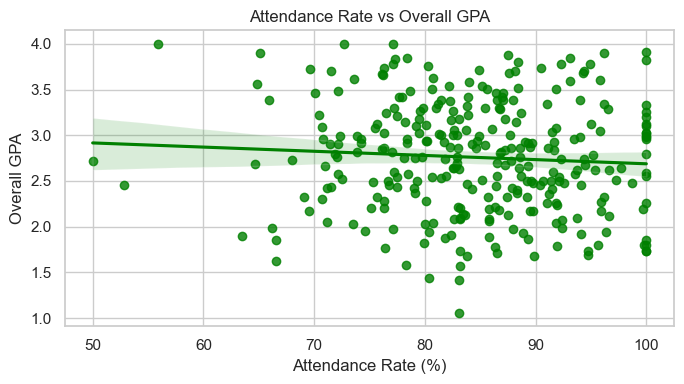

In [25]:
# SECTION 9.2: ATTENDANCE vs GPA

plt.figure(figsize=(7,4))
# Added color="green" parameter to set both scatter points and regression line to green
sns.regplot(data=df_clean, x="attendance_rate", y="overall_gpa", 
            scatter_kws={"alpha":0.8, "color":"green"}, 
            line_kws={"color":"green"})
plt.title("Attendance Rate vs Overall GPA")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Overall GPA")
plt.tight_layout()
plt.show()

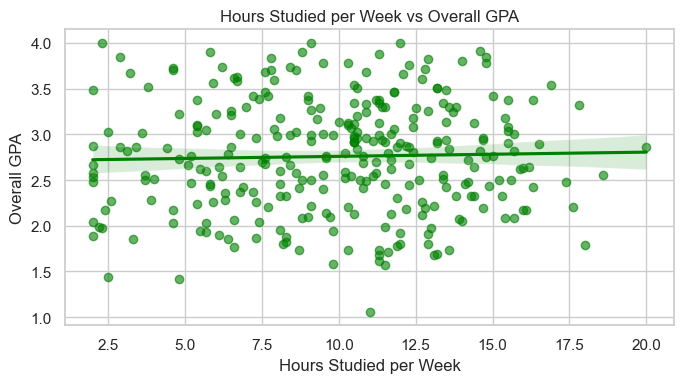

In [27]:
# SECTION 9.3: STUDY HOURS vs GPA

plt.figure(figsize=(7,4))
# Added color="green" parameter to set both scatter points and regression line to green
sns.regplot(data=df_clean, x="hours_studied_per_week", y="overall_gpa", 
            scatter_kws={"alpha":0.6, "color":"green"}, 
            line_kws={"color":"green"})
plt.title("Hours Studied per Week vs Overall GPA")
plt.xlabel("Hours Studied per Week")
plt.ylabel("Overall GPA")
plt.tight_layout()
plt.show()

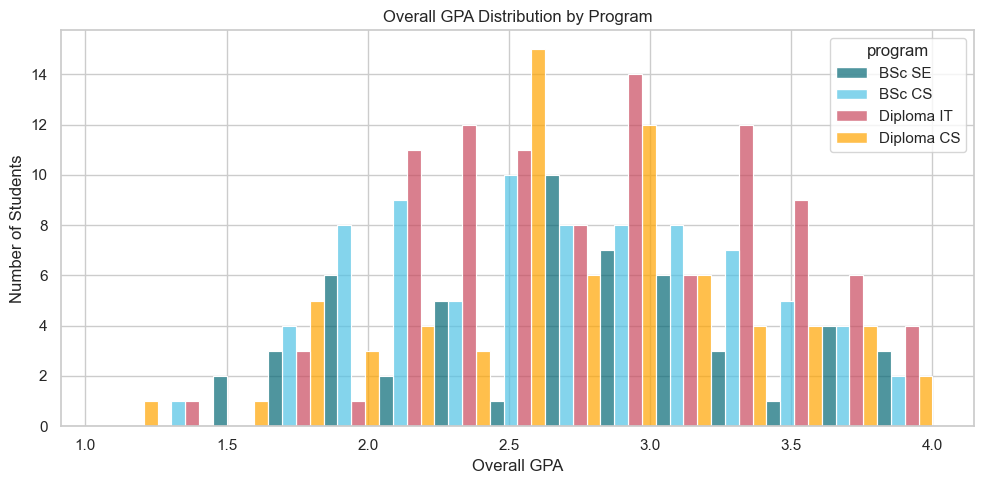

In [33]:
# SECTION 9.4: GPA BY PROGRAM

plt.figure(figsize=(10,5))
# Changed from boxplot to histplot with hue parameter to separate by program
# Using the specified custom colors
custom_palette = ["#056875", "#50C2E5", "#C9495E", "orange"]
sns.histplot(data=df_clean, x="overall_gpa", hue="program", 
             multiple="dodge", palette=custom_palette, 
             alpha=0.7, bins=15)
plt.title("Overall GPA Distribution by Program")
plt.xlabel("Overall GPA")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

C:\Users\Taufique Ahmed\AppData\Local\Temp\ipykernel_7548\1346057160.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="fee_payment_status", y="overall_gpa",


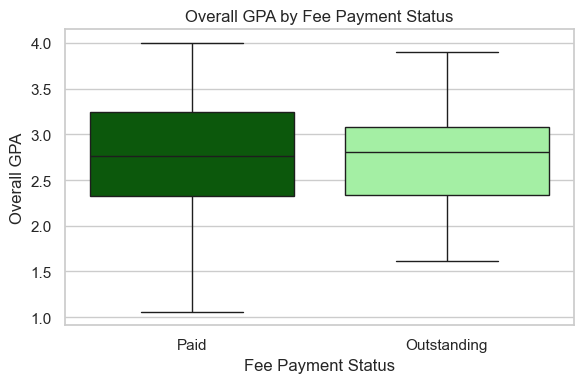

In [37]:
# SECTION 9.5: FEE STATUS vs GPA

plt.figure(figsize=(6,4))
# Changed from default colors to green shades
# Using a dictionary to map fee payment status to specific green colors
# Added 'Outstanding' to the palette dictionary with a light green shade
sns.boxplot(data=df_clean, x="fee_payment_status", y="overall_gpa", 
            palette={"Paid": "darkgreen", "Partial": "mediumseagreen", 
                     "Unpaid": "lightgreen", "Outstanding": "palegreen"})
plt.title("Overall GPA by Fee Payment Status")
plt.xlabel("Fee Payment Status")
plt.ylabel("Overall GPA")
plt.tight_layout()
plt.show()

,age,gpa_sem1,gpa_sem2,attendance_rate,hours_studied_per_week,overall_gpa
age,1.000,-0.010,-0.037,0.007,0.016,-0.025
gpa_sem1,-0.010,1.000,0.816,-0.030,0.044,0.948
gpa_sem2,-0.037,0.816,1.000,-0.099,0.015,0.957
attendance_rate,0.007,-0.030,-0.099,1.000,0.097,-0.069
hours_studied_per_week,0.016,0.044,0.015,0.097,1.000,0.030
overall_gpa,-0.025,0.948,0.957,-0.069,0.030,1.000


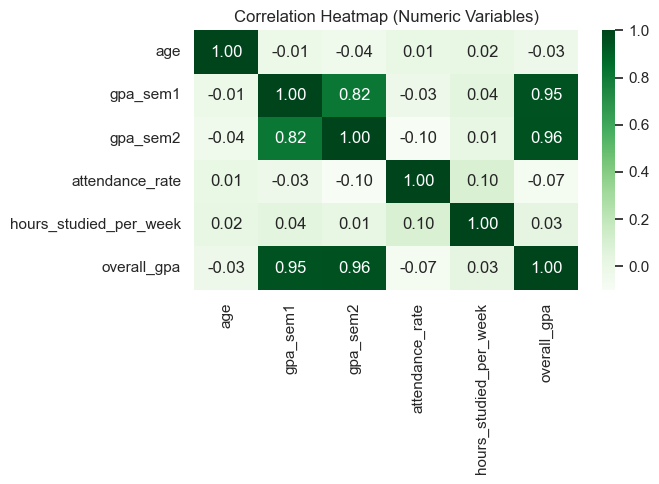

In [9]:
# SECTION 8: CORRELATION ANALYSIS

corr_matrix = df_clean[numeric_cols].corr(numeric_only=True).round(3)
display(corr_matrix)

plt.figure(figsize=(7,5))
# Changed "Green" to "Greens" which is a valid colormap in matplotlib/seaborn
sns.heatmap(corr_matrix, annot=True, cmap="Greens", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()